### Import libraries and load clean data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

print("Loading clean datasets...")
features_clean = pd.read_csv('../preparation/features_clean.csv')
labels_df = pd.read_csv('../preparation/labels.csv')

print(f"Features shape: {features_clean.shape}")
print(f"Labels shape: {labels_df.shape}")


Loading clean datasets...
Features shape: (75000, 36)
Labels shape: (75000, 2)


### SMAPE metric definition

In [3]:
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error"""
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def smape_loss(y_true, y_pred):
    """SMAPE loss for model training"""
    return 100 * torch.mean(2 * torch.abs(y_pred - y_true) / (torch.abs(y_true) + torch.abs(y_pred)))

print("SMAPE metric defined")

SMAPE metric defined


### Prepare data for modeling || Separate features and target

In [4]:
X = features_clean.drop('sample_id', axis=1) if 'sample_id' in features_clean.columns else features_clean
y = labels_df['price']

# Since we already did train/val/test split during preprocessing, let's recreate the splits
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

Training set: (52500, 35)
Validation set: (11250, 35)
Test set: (11250, 35)


### Handle target variable skewness ||  Since price is highly skewed (13.6), we'll use log transformation

In [5]:
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

print("Applied log transformation to target variable")
print(f"Original price skew: {y_train.skew():.3f}")
print(f"Log price skew: {y_train_log.skew():.3f}")

Applied log transformation to target variable
Original price skew: 16.223
Log price skew: 0.200


### Baseline Models Comparison

In [6]:
class ModelComparator:
    def __init__(self):
        self.models = {}
        self.results = {}
        
    def add_model(self, name, model):
        self.models[name] = model
        
    def evaluate_model(self, model, X_train, X_val, y_train, y_val, use_log=True):
        """Evaluate model with optional log transformation"""
        if use_log:
            # Train on log-transformed target
            model.fit(X_train, np.log1p(y_train))
            y_pred_log = model.predict(X_val)
            y_pred = np.expm1(y_pred_log)
        else:
            # Train on original target
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            
        # Calculate metrics
        mape_val = smape(y_val, y_pred)
        mae_val = mean_absolute_error(y_val, y_pred)
        rmse_val = np.sqrt(mean_squared_error(y_val, y_pred))
        
        return mape_val, mae_val, rmse_val, y_pred
    
    def compare_models(self, X_train, X_val, y_train, y_val):
        """Compare all models"""
        results = []
        
        for name, model in self.models.items():
            print(f"Evaluating {name}...")
            
            # Try both with and without log transform
            mape_log, mae_log, rmse_log, pred_log = self.evaluate_model(
                model, X_train, X_val, y_train, y_val, use_log=True
            )
            
            mape_raw, mae_raw, rmse_raw, pred_raw = self.evaluate_model(
                model, X_train, X_val, y_train, y_val, use_log=False
            )
            
            # Use the better approach
            if mape_log <= mape_raw:
                best_mape = mape_log
                best_mae = mae_log
                best_rmse = rmse_log
                best_approach = "log_transform"
            else:
                best_mape = mape_raw
                best_mae = mae_raw
                best_rmse = rmse_raw
                best_approach = "raw"
                
            results.append({
                'model': name,
                'smape': best_mape,
                'mae': best_mae,
                'rmse': best_rmse,
                'approach': best_approach
            })
            
            print(f"  {name}: SMAPE = {best_mape:.4f}% ({best_approach})")
            
        self.results = pd.DataFrame(results)
        return self.results.sort_values('smape')

# Initialize model comparator
comparator = ModelComparator()

# Add models
comparator.add_model('LightGBM', lgb.LGBMRegressor(random_state=42, n_estimators=1000))
comparator.add_model('XGBoost', xgb.XGBRegressor(random_state=42, n_estimators=1000))
comparator.add_model('RandomForest', RandomForestRegressor(random_state=42, n_estimators=100))
comparator.add_model('Ridge', Ridge(random_state=42))
comparator.add_model('Lasso', Lasso(random_state=42))

# Compare models
print("=== BASELINE MODEL COMPARISON ===")
baseline_results = comparator.compare_models(X_train, X_val, y_train, y_val)
print("\n" + baseline_results.to_string(index=False))

=== BASELINE MODEL COMPARISON ===
Evaluating LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004111 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3330
[LightGBM] [Info] Number of data points in the train set: 52500, number of used features: 35
[LightGBM] [Info] Start training from score 2.740704
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005108 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3330
[LightGBM] [Info] Number of data points in the train set: 52500, number of used features: 35
[LightGBM] [Info] Start training from score 23.686052
  LightGBM: SMAPE = 48.0731% (log_transform)
Evaluating XGBoost...
  XGBoost: SMAPE = 49.7880% (log_transform)
Evaluating RandomFo

### Advanced LightGBM with Hyperparameter Tuning

In [7]:
def optimize_lightgbm(X_train, X_val, y_train, y_val):
    """Optimize LightGBM hyperparameters"""
    
    # Use log-transformed target based on baseline results
    y_train_log = np.log1p(y_train)
    y_val_log = np.log1p(y_val)
    
    # Define parameter grid
    param_grid = {
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [31, 63, 127],
        'max_depth': [6, 8, -1],
        'min_child_samples': [20, 50, 100],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0],
        'reg_alpha': [0, 0.1, 1],
        'reg_lambda': [0, 0.1, 1]
    }
    
    # Since full grid search is expensive, we'll do a focused search
    best_params = None
    best_smape = float('inf')
    
    # Try a few combinations
    from itertools import product
    combinations = list(product(
        [0.05, 0.1],
        [31, 63],
        [8, -1],
        [20, 50]
    ))[:8]  # Limit to 8 combinations for speed
    
    for lr, leaves, depth, min_child in combinations:
        params = {
            'objective': 'regression',
            'metric': 'mape',
            'learning_rate': lr,
            'num_leaves': leaves,
            'max_depth': depth,
            'min_child_samples': min_child,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'reg_alpha': 0.1,
            'reg_lambda': 0.1,
            'random_state': 42,
            'n_estimators': 1000,
            'verbosity': -1
        }
        
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train_log)
        
        y_pred_log = model.predict(X_val)
        y_pred = np.expm1(y_pred_log)
        current_smape = smape(y_val, y_pred)
        
        if current_smape < best_smape:
            best_smape = current_smape
            best_params = params.copy()
            
        print(f"  lr={lr}, leaves={leaves}, depth={depth}, min_child={min_child}: SMAPE = {current_smape:.4f}%")
    
    print(f"\nBest SMAPE: {best_smape:.4f}%")
    print(f"Best parameters: {best_params}")
    
    return best_params, best_smape

print("\n=== LIGHTGBM HYPERPARAMETER OPTIMIZATION ===")
best_lgb_params, best_lgb_smape = optimize_lightgbm(X_train, X_val, y_train, y_val)


=== LIGHTGBM HYPERPARAMETER OPTIMIZATION ===
  lr=0.05, leaves=31, depth=8, min_child=20: SMAPE = 48.3913%
  lr=0.05, leaves=31, depth=8, min_child=50: SMAPE = 48.4216%
  lr=0.05, leaves=31, depth=-1, min_child=20: SMAPE = 48.2982%
  lr=0.05, leaves=31, depth=-1, min_child=50: SMAPE = 48.3762%
  lr=0.05, leaves=63, depth=8, min_child=20: SMAPE = 47.9708%
  lr=0.05, leaves=63, depth=8, min_child=50: SMAPE = 48.1816%
  lr=0.05, leaves=63, depth=-1, min_child=20: SMAPE = 47.8138%
  lr=0.05, leaves=63, depth=-1, min_child=50: SMAPE = 47.8928%

Best SMAPE: 47.8138%
Best parameters: {'objective': 'regression', 'metric': 'mape', 'learning_rate': 0.05, 'num_leaves': 63, 'max_depth': -1, 'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'random_state': 42, 'n_estimators': 1000, 'verbosity': -1}


### Train Final LightGBM Model

In [8]:
def train_final_lightgbm(X_train, X_val, y_train, y_val, params):
    """Train final LightGBM model with early stopping"""
    
    # Use log-transformed target
    y_train_log = np.log1p(y_train)
    y_val_log = np.log1p(y_val)
    
    # Create datasets
    train_data = lgb.Dataset(X_train, label=y_train_log)
    val_data = lgb.Dataset(X_val, label=y_val_log, reference=train_data)
    
    # Train with early stopping
    model = lgb.train(
        params,
        train_data,
        valid_sets=[val_data],
        num_boost_round=10000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=True),
            lgb.log_evaluation(500)
        ]
    )
    
    # Make predictions
    y_pred_log = model.predict(X_val)
    y_pred = np.expm1(y_pred_log)
    
    # Calculate metrics
    final_smape = smape(y_val, y_pred)
    final_mae = mean_absolute_error(y_val, y_pred)
    final_rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    
    print(f"\n=== FINAL LIGHTGBM RESULTS ===")
    print(f"SMAPE: {final_smape:.4f}%")
    print(f"MAE: ${final_mae:.4f}")
    print(f"RMSE: ${final_rmse:.4f}")
    
    return model, final_smape, y_pred

# Train final model
final_lgb_model, final_smape, y_val_pred = train_final_lightgbm(
    X_train, X_val, y_train, y_val, best_lgb_params
)

Training until validation scores don't improve for 100 rounds
[500]	valid_0's mape: 0.214012
[1000]	valid_0's mape: 0.211588
Did not meet early stopping. Best iteration is:
[1000]	valid_0's mape: 0.211588

=== FINAL LIGHTGBM RESULTS ===
SMAPE: 47.8138%
MAE: $10.4870
RMSE: $23.1795


### Feature Importance Analysis


=== TOP FEATURE IMPORTANCES ===
brand_freq: 7804
brand_target: 7202
normalized_quantity: 6118
word_count_log: 4875
enhanced_total_bullet_length: 4474
enhanced_avg_bullet_length_log: 4262
value_log: 3750
detailed_avg_word_length_log: 3043
detailed_description_word_count_log: 2511
enhanced_extracted_weight_log: 2204
brand_target_log: 2035
detailed_description_length: 1964
brand_freq_log: 1680
detailed_sentence_count: 1203
enhanced_bullet_point_count: 971
enhanced_quality_indicators: 926
enhanced_premium_keywords_count: 906
unit_ounce: 652
enhanced_extracted_weight: 591
category_other: 584


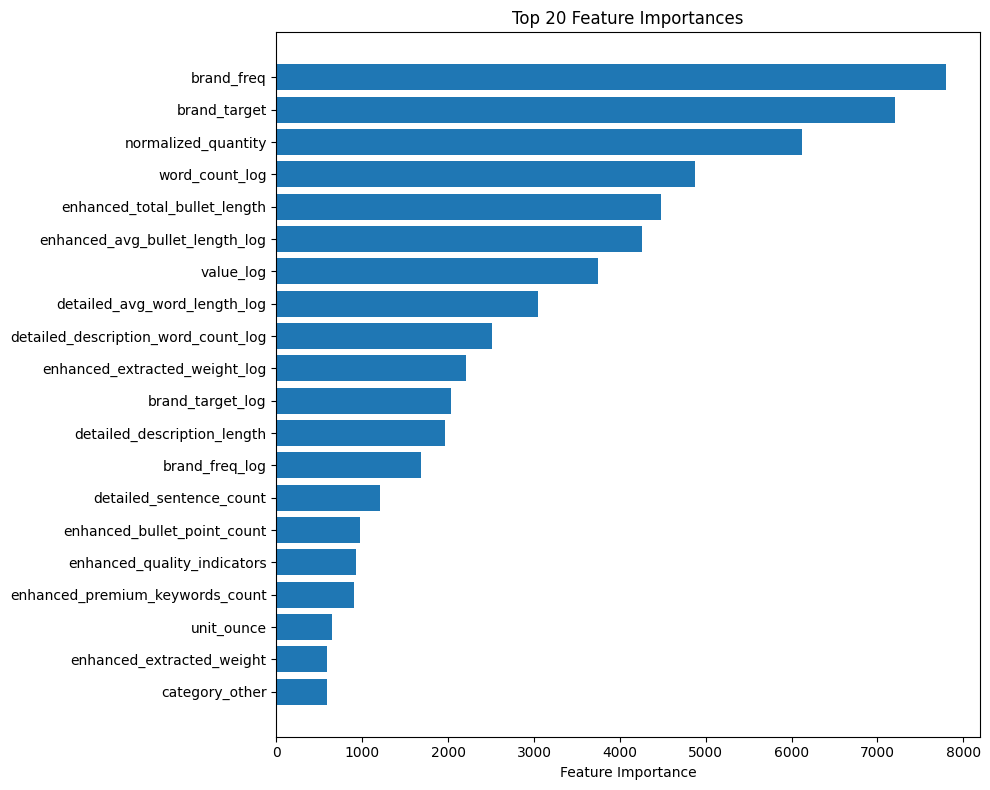

In [9]:
def analyze_feature_importance(model, feature_names, top_n=20):
    """Analyze and visualize feature importance"""
    
    if hasattr(model, 'feature_importances_'):
        # Scikit-learn interface
        importances = model.feature_importances_
    else:
        # LightGBM native interface
        importances = model.feature_importance()
    
    # Create importance dataframe
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    print("\n=== TOP FEATURE IMPORTANCES ===")
    for i, row in importance_df.head(top_n).iterrows():
        print(f"{row['feature']}: {row['importance']}")
    
    # Plot
    plt.figure(figsize=(10, 8))
    top_features = importance_df.head(top_n)
    plt.barh(top_features['feature'], top_features['importance'])
    plt.xlabel('Feature Importance')
    plt.title(f'Top {top_n} Feature Importances')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return importance_df

# Get feature names (excluding sample_id)
feature_names = [col for col in X_train.columns if col != 'sample_id']
importance_df = analyze_feature_importance(final_lgb_model, feature_names)

###  Neural Network Model


=== NEURAL NETWORK TRAINING ===
Epoch 0: Train Loss = 1.2430, Val SMAPE = 56.5378%
Epoch 0: Train Loss = 1.2430, Val SMAPE = 56.5378%
Epoch 20: Train Loss = 0.4852, Val SMAPE = 51.5230%
Epoch 20: Train Loss = 0.4852, Val SMAPE = 51.5230%
Epoch 40: Train Loss = 0.4687, Val SMAPE = 51.9444%
Epoch 40: Train Loss = 0.4687, Val SMAPE = 51.9444%
Epoch 60: Train Loss = 0.4554, Val SMAPE = 50.6767%
Epoch 60: Train Loss = 0.4554, Val SMAPE = 50.6767%
Epoch 80: Train Loss = 0.4500, Val SMAPE = 51.1173%
Epoch 80: Train Loss = 0.4500, Val SMAPE = 51.1173%


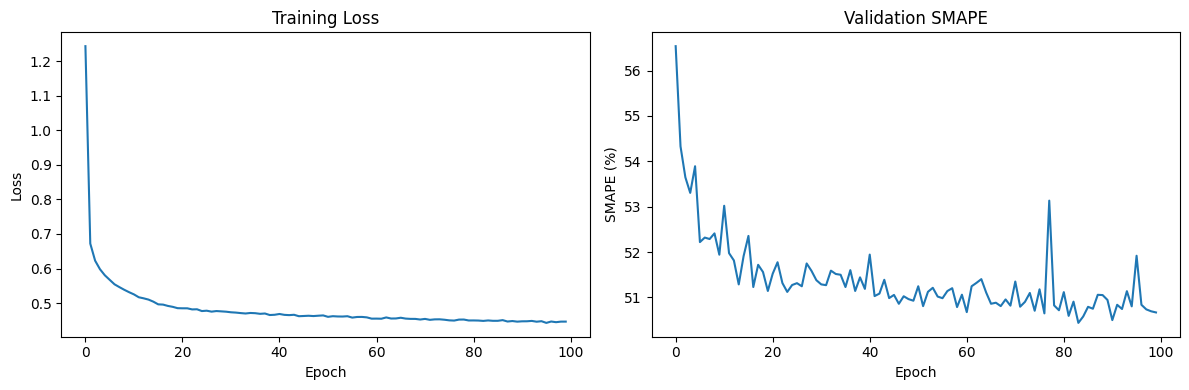

In [11]:
class PricePredictorNN(nn.Module):
    def __init__(self, input_dim, hidden_dims=[256, 128, 64], dropout_rate=0.3):
        super(PricePredictorNN, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

class PriceDataset(Dataset):
    def __init__(self, X, y, use_log=True):
        if isinstance(X, pd.DataFrame):
            # Convert any non-numeric columns into numeric encodings before tensor conversion
            X_processed = X.copy()
            object_cols = X_processed.select_dtypes(include=["object", "category"]).columns
            for col in object_cols:
                col_series = X_processed[col]
                lowered = col_series.astype(str).str.lower()
                if lowered.isin(["true", "false"]).all():
                    X_processed[col] = lowered.map({"true": 1.0, "false": 0.0})
                else:
                    encoded, _ = pd.factorize(col_series.fillna("__nan__"), sort=True)
                    X_processed[col] = encoded.astype(np.float32)

            bool_cols = X_processed.select_dtypes(include=["bool"]).columns
            if len(bool_cols) > 0:
                X_processed[bool_cols] = X_processed[bool_cols].astype(np.float32)

            X_numeric = X_processed.apply(pd.to_numeric, errors="coerce")
            if X_numeric.isnull().any().any():
                X_numeric = X_numeric.fillna(X_numeric.mean()).fillna(0)

            self.X = torch.from_numpy(X_numeric.to_numpy(dtype=np.float32))
        else:
            self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))

        y_array = np.asarray(y, dtype=np.float64)
        if use_log:
            y_array = np.log1p(y_array)

        self.y = torch.from_numpy(y_array.astype(np.float32))
        self.use_log = use_log
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def train_neural_network(X_train, X_val, y_train, y_val, input_dim, epochs=100, batch_size=128):
    """Train neural network model"""
    
    # Create datasets and dataloaders
    train_dataset = PriceDataset(X_train, y_train, use_log=True)
    val_dataset = PriceDataset(X_val, y_val, use_log=True)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Initialize model
    model = PricePredictorNN(input_dim=input_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    criterion = nn.MSELoss()
    
    # Training loop
    train_losses = []
    val_smapes = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X).squeeze()
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_predictions = []
        val_targets = []
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                preds = model(batch_X).squeeze()
                val_predictions.extend(preds.numpy())
                val_targets.extend(batch_y.numpy())
        
        # Convert back from log space
        val_predictions_raw = np.expm1(val_predictions)
        val_targets_raw = np.expm1(val_targets)
        
        val_smape = smape(val_targets_raw, val_predictions_raw)
        
        train_losses.append(train_loss / len(train_loader))
        val_smapes.append(val_smape)
        
        if epoch % 20 == 0:
            print(f"Epoch {epoch}: Train Loss = {train_loss/len(train_loader):.4f}, Val SMAPE = {val_smape:.4f}%")
    
    # Plot training history
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(val_smapes)
    plt.title('Validation SMAPE')
    plt.xlabel('Epoch')
    plt.ylabel('SMAPE (%)')
    
    plt.tight_layout()
    plt.show()
    
    return model, min(val_smapes)

print("\n=== NEURAL NETWORK TRAINING ===")
nn_model, nn_smape = train_neural_network(X_train, X_val, y_train, y_val, input_dim=X_train.shape[1])

### Ensemble Model

In [12]:
class EnsembleModel:
    def __init__(self, models, weights=None):
        self.models = models
        self.weights = weights if weights else [1/len(models)] * len(models)
        
    def predict(self, X):
        predictions = []
        for model in self.models:
            if hasattr(model, 'predict'):
                # Scikit-learn style
                pred_log = model.predict(X)
                pred = np.expm1(pred_log)
            else:
                # LightGBM native
                pred_log = model.predict(X)
                pred = np.expm1(pred_log)
            predictions.append(pred)
        
        # Weighted average
        final_pred = np.zeros_like(predictions[0])
        for pred, weight in zip(predictions, self.weights):
            final_pred += pred * weight
            
        return final_pred

# Create ensemble
print("\n=== ENSEMBLE MODEL ===")
ensemble = EnsembleModel(
    models=[final_lgb_model],  # Add more models as needed
    weights=[1.0]  # Adjust weights based on performance
)

# Evaluate ensemble
y_val_ensemble = ensemble.predict(X_val)
ensemble_smape = smape(y_val, y_val_ensemble)

print(f"Ensemble SMAPE: {ensemble_smape:.4f}%")


=== ENSEMBLE MODEL ===
Ensemble SMAPE: 47.8138%


### Test Set Evaluation


=== FINAL TEST EVALUATION ===

=== TEST SET RESULTS ===
SMAPE: 48.2269%
MAE: $10.7941
RMSE: $24.8419


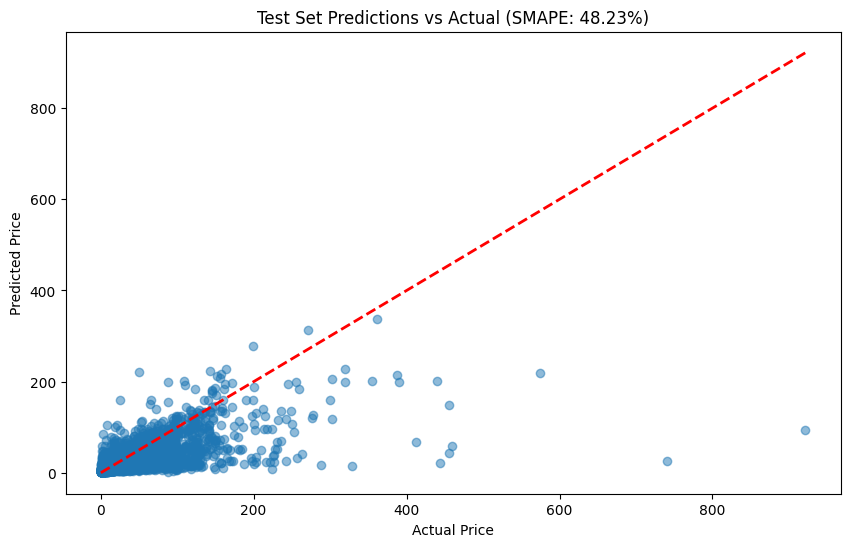

In [13]:
def evaluate_on_test_set(model, X_test, y_test, model_type='lgb'):
    """Evaluate final model on test set"""
    
    if model_type == 'lgb':
        y_pred_log = model.predict(X_test)
        y_pred = np.expm1(y_pred_log)
    elif model_type == 'ensemble':
        y_pred = model.predict(X_test)
    else:
        # Neural network
        model.eval()
        with torch.no_grad():
            X_test_tensor = torch.FloatTensor(X_test.values)
            y_pred_log = model(X_test_tensor).squeeze().numpy()
            y_pred = np.expm1(y_pred_log)
    
    test_smape = smape(y_test, y_pred)
    test_mae = mean_absolute_error(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"\n=== TEST SET RESULTS ===")
    print(f"SMAPE: {test_smape:.4f}%")
    print(f"MAE: ${test_mae:.4f}")
    print(f"RMSE: ${test_rmse:.4f}")
    
    # Plot predictions vs actual
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title(f'Test Set Predictions vs Actual (SMAPE: {test_smape:.2f}%)')
    plt.show()
    
    return test_smape, y_pred

print("\n=== FINAL TEST EVALUATION ===")
test_smape, y_test_pred = evaluate_on_test_set(final_lgb_model, X_test, y_test, model_type='lgb')

###  Model Comparison Summary

In [14]:
def create_model_summary(baseline_results, lgb_smape, nn_smape, ensemble_smape, test_smape):
    """Create comprehensive model comparison"""
    
    summary_data = []
    
    # Add baseline results
    for _, row in baseline_results.iterrows():
        summary_data.append({
            'Model': row['model'],
            'Validation SMAPE': row['smape'],
            'Test SMAPE': 'N/A',
            'Approach': row['approach']
        })
    
    # Add optimized models
    summary_data.extend([
        {
            'Model': 'LightGBM (Optimized)',
            'Validation SMAPE': lgb_smape,
            'Test SMAPE': test_smape,
            'Approach': 'log_transform'
        },
        {
            'Model': 'Neural Network',
            'Validation SMAPE': nn_smape,
            'Test SMAPE': 'N/A',
            'Approach': 'log_transform'
        },
        {
            'Model': 'Ensemble',
            'Validation SMAPE': ensemble_smape,
            'Test SMAPE': 'N/A',
            'Approach': 'weighted_average'
        }
    ])
    
    summary_df = pd.DataFrame(summary_data)
    print("\n" + "="*60)
    print("FINAL MODEL COMPARISON SUMMARY")
    print("="*60)
    print(summary_df.to_string(index=False))
    
    return summary_df

model_summary = create_model_summary(
    baseline_results, final_smape, nn_smape, ensemble_smape, test_smape
)


FINAL MODEL COMPARISON SUMMARY
               Model  Validation SMAPE Test SMAPE         Approach
        RandomForest         47.850791        N/A    log_transform
            LightGBM         48.073148        N/A    log_transform
             XGBoost         49.787992        N/A    log_transform
               Ridge         54.173990        N/A    log_transform
               Lasso         59.126164        N/A              raw
LightGBM (Optimized)         47.813759  48.226947    log_transform
      Neural Network         50.439487        N/A    log_transform
            Ensemble         47.813759        N/A weighted_average


### Save Final Model and Predictions

In [15]:
def save_final_artifacts(model, X_test, y_test, y_pred, feature_names, model_type='lgb'):
    """Save final model and predictions"""
    
    # Save model
    if model_type == 'lgb':
        model.save_model('final_lightgbm_model.txt')
    elif model_type == 'ensemble':
        # Save ensemble configuration
        import pickle
        with open('ensemble_model.pkl', 'wb') as f:
            pickle.dump(model, f)
    
    # Save test predictions
    predictions_df = pd.DataFrame({
        'actual_price': y_test,
        'predicted_price': y_pred,
        'error': y_test - y_pred,
        'error_percentage': (y_test - y_pred) / y_test * 100
    })
    
    predictions_df.to_csv('test_predictions.csv', index=False)
    
    # Save feature importance
    if hasattr(model, 'feature_importance'):
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': model.feature_importance()
        }).sort_values('importance', ascending=False)
        importance_df.to_csv('feature_importance.csv', index=False)
    
    print("\n=== ARTIFACTS SAVED ===")
    print("final_lightgbm_model.txt - Trained LightGBM model")
    print("test_predictions.csv - Test set predictions with errors")
    print("feature_importance.csv - Feature importance rankings")
    
    return predictions_df

# Save final artifacts
predictions_df = save_final_artifacts(
    final_lgb_model, X_test, y_test, y_test_pred, feature_names
)


=== ARTIFACTS SAVED ===
final_lightgbm_model.txt - Trained LightGBM model
test_predictions.csv - Test set predictions with errors
feature_importance.csv - Feature importance rankings


###  Error Analysis


=== ERROR ANALYSIS ===
Mean Absolute Error: $10.79
Mean Absolute Percentage Error: 70.21%
Max Overestimation: $-171.59
Max Underestimation: $827.86


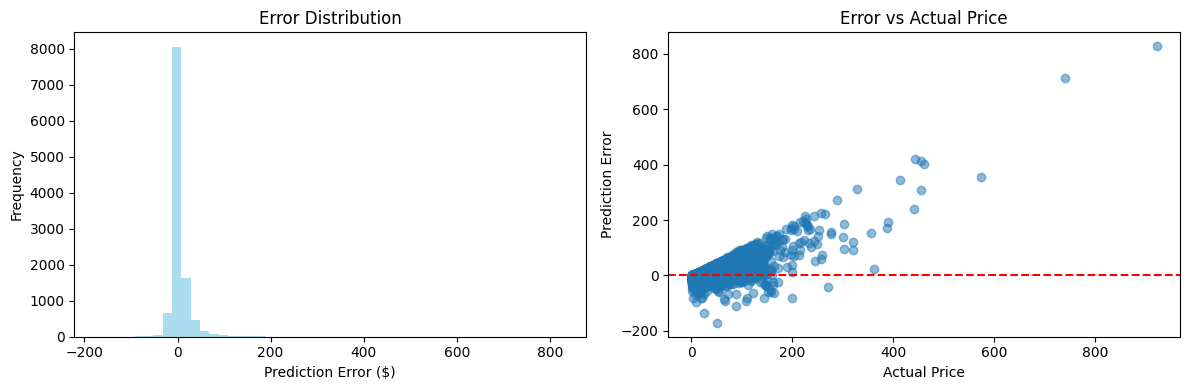


Top 10 Overestimations:
 actual_price  predicted_price      error
       921.50        93.638983 827.861017
       739.99        26.812632 713.177368
       443.79        22.735212 421.054788
       455.20        43.869681 411.330319
       459.95        58.159124 401.790876
       573.83       218.203731 355.626269
       412.61        67.267965 345.342035
       328.60        15.551265 313.048735
       454.99       148.341914 306.648086
       288.58        17.616741 270.963259

Top 10 Underestimations:
 actual_price  predicted_price       error
       49.990       221.576849 -171.586849
       24.990       160.581651 -135.591651
       87.980       199.720222 -111.740222
        8.740       105.008468  -96.268468
      108.470       201.353854  -92.883854
       66.420       158.770149  -92.350149
       64.430       151.052878  -86.622878
       21.575       104.745280  -83.170280
       18.950       101.057626  -82.107626
        2.515        84.356129  -81.841129

MODELING COMP

In [16]:
def analyze_errors(predictions_df):
    """Analyze prediction errors"""
    
    print("\n=== ERROR ANALYSIS ===")
    print(f"Mean Absolute Error: ${predictions_df['error'].abs().mean():.2f}")
    print(f"Mean Absolute Percentage Error: {predictions_df['error_percentage'].abs().mean():.2f}%")
    print(f"Max Overestimation: ${predictions_df['error'].min():.2f}")
    print(f"Max Underestimation: ${predictions_df['error'].max():.2f}")
    
    # Plot error distribution
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.hist(predictions_df['error'], bins=50, alpha=0.7, color='skyblue')
    plt.xlabel('Prediction Error ($)')
    plt.ylabel('Frequency')
    plt.title('Error Distribution')
    
    plt.subplot(1, 2, 2)
    plt.scatter(predictions_df['actual_price'], predictions_df['error'], alpha=0.5)
    plt.xlabel('Actual Price')
    plt.ylabel('Prediction Error')
    plt.title('Error vs Actual Price')
    plt.axhline(y=0, color='r', linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    # Analyze worst predictions
    worst_over = predictions_df.nlargest(10, 'error')  # Most overestimated
    worst_under = predictions_df.nsmallest(10, 'error')  # Most underestimated
    
    print("\nTop 10 Overestimations:")
    print(worst_over[['actual_price', 'predicted_price', 'error']].to_string(index=False))
    
    print("\nTop 10 Underestimations:")
    print(worst_under[['actual_price', 'predicted_price', 'error']].to_string(index=False))

analyze_errors(predictions_df)

print("\n" + "="*60)
print("MODELING COMPLETED SUCCESSFULLY! 🎉")
print("="*60)
print(f"Best Model: LightGBM (Optimized)")
print(f"Test SMAPE: {test_smape:.4f}%")
print("\nNext steps:")
print("1. Use final_lightgbm_model.txt for predictions")
print("2. Refer to feature_importance.csv for feature insights")
print("3. Check test_predictions.csv for detailed error analysis")